This notebook looks at next-day GB electricity system price forecasting using ONS daily system price data. I compare a few simple baselines with a feature-based model and split the data in time order so future values are not used by mistake.

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

## Dataset

The ONS dataset has the daily average System Price (£/MWh) and a pre-computed 7-day rolling average. I do not use the ONS rolling average directly because I want to create my own rolling features later.

In [3]:
DATA_RAW = Path("../data/raw")

df = pd.read_excel(DATA_RAW/"electricity_prices_dataset_ONS.xlsx", sheet_name="1.Daily SP Electricity", header = 4)
df.columns = ["date", "price", "ons_7day"]
df = df[["date", "price"]].copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Rows:", len(df))
print("Start date:", df["date"].min().date())
print("End date:", df["date"].max().date())
df.head(10)

Rows: 2280
Start date: 2020-01-01
End date: 2026-03-29


,date,price
0,2020-01-01,3.951209
1,2020-01-02,1.771417
2,2020-01-03,2.135458
3,2020-01-04,2.699667
4,2020-01-05,2.758000
5,2020-01-06,3.471598
6,2020-01-07,2.875125
7,2020-01-08,3.053792
8,2020-01-09,3.061168
9,2020-01-10,4.486438


## Looking at the data

In [4]:
df["price"].describe()

count    2280.000000
mean        9.865304
std         7.421379
min        -1.691145
25%         5.409318
50%         8.264948
75%        11.475538
max        77.790390
Name: price, dtype: float64

I was interested to see that electricity prices can briefly become negative. This usually happens when supply is very high and demand is low, so excess power in the market pushes prices below zero for a short time.

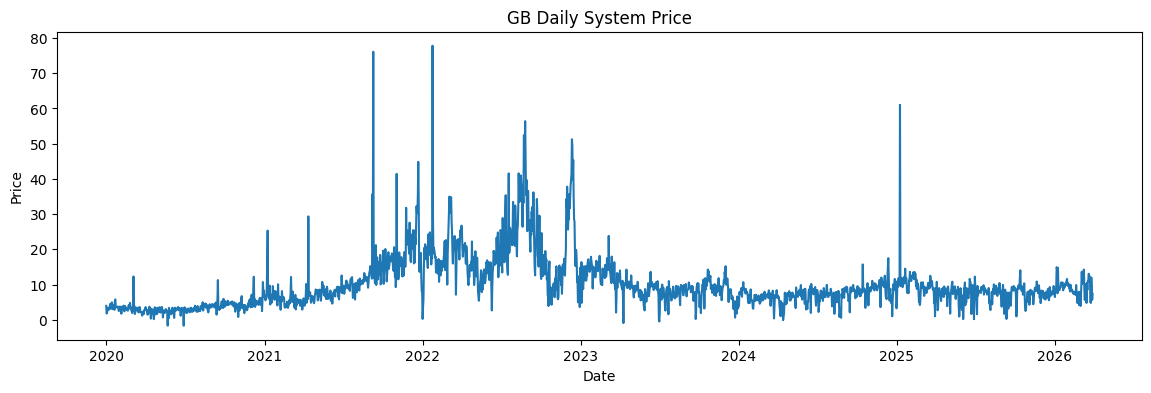

In [5]:
plt.figure(figsize=(14, 4))
plt.plot(df["date"], df["price"])
plt.title("GB Daily System Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

The prices move around a lot, so I started by checking some simple baselines before trying a more complex model.

## Notes on the chart

This chart shows the daily electricity price over time.

A few simple things stand out:

- In the earlier years, prices are generally lower and more stable.
- From late 2021 into 2022, prices become much more volatile and there are several very large spikes.
- After that period, prices come down again, but the market still shows some sudden jumps.

This suggests that electricity prices do not behave in a completely stable way over time. Some periods are relatively calm, while others are much more unpredictable. That matters for forecasting, because a model that works reasonably well in stable periods may struggle during sharp market shocks.

This is also broadly in line with what I expected to see. Energy prices are influenced by real-world events, and the large increase in volatility around 2021–2022 fits with the wider energy crisis and the disruption that followed the war in Ukraine.

## Baselines

In [6]:
df["baseline_prev_day"] = df["price"].shift(1)
df["baseline_prev_week"] = df["price"].shift(7)
df["baseline_7day_mean"] = df["price"].shift(1).rolling(7).mean()

## Feature Engineering

In [7]:
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df["lag_1"] = df["price"].shift(1)
df["lag_2"] = df["price"].shift(2)
df["lag_7"] = df["price"].shift(7)
df["lag_14"] = df["price"].shift(14)

df["rolling_mean_7"] = df["price"].shift(1).rolling(7).mean()
df["rolling_mean_14"] = df["price"].shift(1).rolling(14).mean()
df["rolling_std_7"] = df["price"].shift(1).rolling(7).std()

feature_df = df.dropna().copy()

print("Rows after feature creation:", len(feature_df))
feature_df.head()

Rows after feature creation: 2266


,date,price,baseline_prev_day,baseline_prev_week,baseline_7day_mean,day_of_week,month,is_weekend,lag_1,lag_2,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7
14,2020-01-15,3.006423,4.950083,3.053792,3.723627,2,1,0,4.950083,3.688708,3.053792,3.951209,3.723627,3.266276,0.731535
15,2020-01-16,3.921416,3.006423,3.061168,3.716860,3,1,0,3.006423,4.950083,3.061168,1.771417,3.716860,3.198791,0.738946
16,2020-01-17,3.107968,3.921416,4.486438,3.839753,4,1,0,3.921416,3.006423,4.486438,2.135458,3.839753,3.352363,0.680984
17,2020-01-18,3.823595,3.107968,3.266721,3.642829,5,1,1,3.107968,3.921416,3.266721,2.699667,3.642829,3.421828,0.661852
18,2020-01-19,4.138275,3.823595,3.558479,3.722382,6,1,1,3.823595,3.107968,3.558479,2.758000,3.722382,3.502108,0.642289


## Train / Validate / test

In [8]:
train = feature_df[feature_df["date"] <= "2024-12-31"].copy()
val = feature_df[(feature_df["date"] > "2024-12-31") & (feature_df["date"] <= "2025-10-31")].copy()
test = feature_df[feature_df["date"] > "2025-10-31"].copy()

feature_cols = [
    "day_of_week", "month", "is_weekend",
    "lag_1", "lag_2", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_mean_14", "rolling_std_7"
]

X_train = train[feature_cols]
y_train = train["price"]

X_val = val[feature_cols]
y_val = val["price"]

X_test = test[feature_cols]
y_test = test["price"]

print("Train size:", len(train))
print("Validation size:", len(val))
print("Test size:", len(test))

Train size: 1813
Validation size: 304
Test size: 149


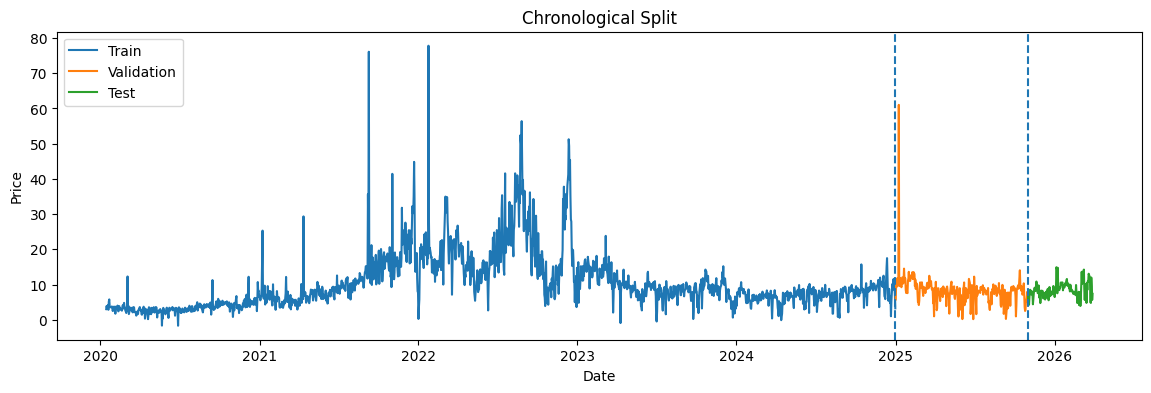

In [9]:
plt.figure(figsize=(14, 4))
plt.plot(train["date"], train["price"], label="Train")
plt.plot(val["date"], val["price"], label="Validation")
plt.plot(test["date"], test["price"], label="Test")
plt.axvline(pd.Timestamp("2024-12-31"), linestyle="--")
plt.axvline(pd.Timestamp("2025-10-31"), linestyle="--")
plt.title("Chronological Split")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## Compare baseline models on the validation. set

In [10]:
def calculate_errors(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

results = []

mae, rmse = calculate_errors(y_val, val["lag_1"])
results.append(["Persistence (previous day)", mae, rmse])

mae, rmse = calculate_errors(y_val, val["lag_7"])
results.append(["Seasonal naive (previous week)", mae, rmse])

mae, rmse = calculate_errors(y_val, val["rolling_mean_7"])
results.append(["7-day rolling mean", mae, rmse])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_val_pred = ridge_model.predict(X_val_scaled)

mae, rmse = calculate_errors(y_val, ridge_val_pred)
results.append(["Ridge regression", mae, rmse])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE"])
results_df


,Model,MAE,RMSE
0,Persistence (previous day),2.103328,4.784655
1,Seasonal naive (previous week),2.789598,5.344462
2,7-day rolling mean,2.123605,3.924251
3,Ridge regression,1.884016,3.809997


## Gradient Boosting

In [11]:
gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(X_train, y_train)
gb_val_pred = gb_model.predict(X_val)

mae, rmse = calculate_errors(y_val, gb_val_pred)
results_df.loc[len(results_df)] = ["Gradient boosting", mae, rmse]

results_df.sort_values("RMSE")


,Model,MAE,RMSE
3,Ridge regression,1.884016,3.809997
4,Gradient boosting,1.900017,3.838158
2,7-day rolling mean,2.123605,3.924251
0,Persistence (previous day),2.103328,4.784655
1,Seasonal naive (previous week),2.789598,5.344462


In [12]:
final_train = feature_df[feature_df["date"] <= "2025-10-31"].copy()
final_test = feature_df[feature_df["date"] > "2025-10-31"].copy()

X_final_train = final_train[feature_cols]
y_final_train = final_train["price"]

X_final_test = final_test[feature_cols]
y_final_test = final_test["price"]

final_model = GradientBoostingRegressor(learning_rate=0.05,random_state=42)

final_model.fit(X_final_train, y_final_train)
test_pred = final_model.predict(X_final_test)

test_mae, test_rmse = calculate_errors(y_final_test, test_pred)
print("Test MAE:", round(test_mae, 3))
print("Test RMSE:", round(test_rmse, 3))

Test MAE: 1.337
Test RMSE: 1.898


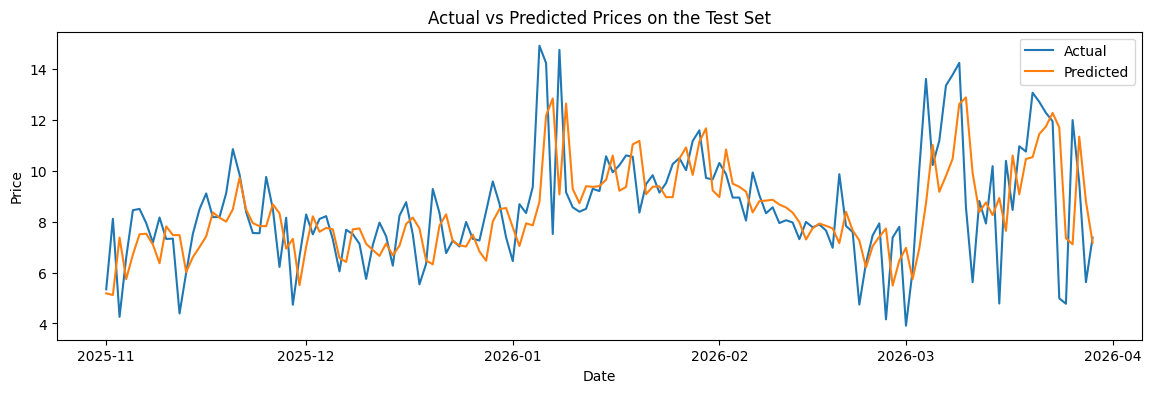

In [13]:
# plot actual vs predicted
plt.figure(figsize=(14, 4))
plt.plot(final_test["date"], y_final_test.values, label="Actual")
plt.plot(final_test["date"], test_pred, label="Predicted")
plt.title("Actual vs Predicted Prices on the Test Set")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## Performance on more volatile days

In [14]:
final_test = final_test.copy()
final_test["predicted_price"] = test_pred
final_test["abs_error"] = np.abs(final_test["price"] - final_test["predicted_price"])
final_test["day_change"] = final_test["price"].diff().abs()

median_change = final_test["day_change"].median()

volatile_days = final_test[final_test["day_change"] > median_change]
calmer_days = final_test[final_test["day_change"] <= median_change]

print("Average absolute error on calmer days:", round(calmer_days["abs_error"].mean(), 3))
print("Average absolute error on more volatile days:", round(volatile_days["abs_error"].mean(), 3))

Average absolute error on calmer days: 0.649
Average absolute error on more volatile days: 2.042


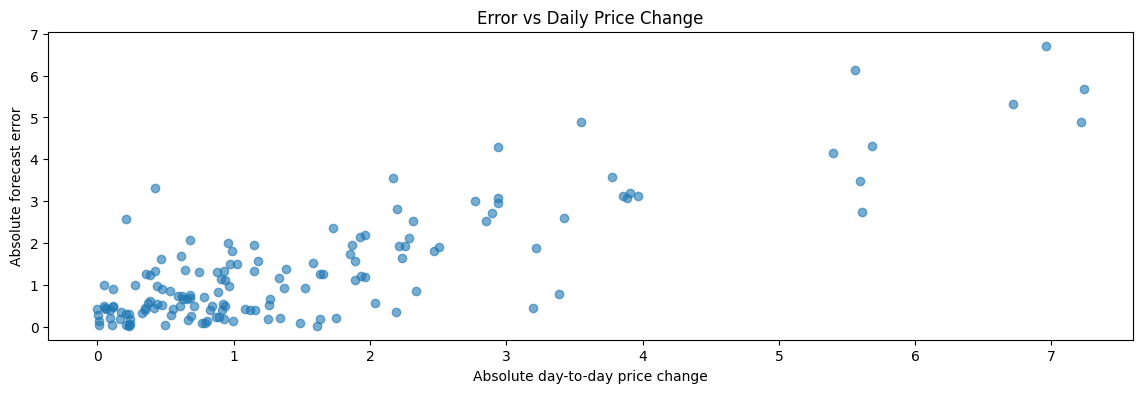

In [15]:
plt.figure(figsize=(14, 4))
plt.scatter(final_test["day_change"], final_test["abs_error"], alpha=0.6)
plt.title("Error vs Daily Price Change")
plt.xlabel("Absolute day-to-day price change")
plt.ylabel("Absolute forecast error")
plt.show()

## Summary
The simple baselines were useful as a starting point, but the gradient boosting model picked up more of the short-term movement in the data. At the same time, it still became less reliable on more volatile days, so that is important to keep in mind when judging the results.